# Harmonized preprocessing for hierarchical seizure classification

**Datasets:** CHB-MIT scalp EEG (PhysioNet) and Siena Scalp EEG (PhysioNet).

**Task this feeds:**

```
Stage 1 (CHB-MIT + Siena)   seizure  vs  non-seizure
                 |
                 +-- if seizure --> Stage 2 (Siena only)
                                    IAS / WIAS / FBTC  (ILAE seizure subtype)
```

CHB-MIT only distinguishes seizure vs. non-seizure; it carries no subtype label, so Stage 2
can only be trained and evaluated on Siena. That asymmetry is a structural property of the
data, not a modelling choice, and it shapes several decisions below.

**What this notebook does:** parses both datasets' native annotation formats into a single
seizure-interval representation, harmonizes both to one 18-channel bipolar montage at one
sampling rate, filters, and emits two labelled window manifests (Stage 1 and Stage 2) plus
the harmonized per-recording signal files they reference. Model training notebooks should
read the manifests in `data/harmonized/windows/` and never touch raw EDF directly.

**Scope note:** this notebook only produces data. `src/train.ipynb`'s current binary 1D CNN
reads a different, older `.npy` format from `data/preprocessed/` and is left untouched here;
teaching it (or a new notebook) to consume the Stage 1 / Stage 2 manifests produced below is
a separate follow-up.


## 0. Setup

In [1]:
import gc
import json
import re
import warnings
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 20260803
rng = np.random.default_rng(SEED)

print(f"mne {mne.__version__} | numpy {np.__version__} | pandas {pd.__version__} | h5py {h5py.__version__}")


mne 1.12.0 | numpy 2.4.3 | pandas 3.0.5 | h5py 3.16.0


C:\Adithya\eeg_hdc\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0.1 Paths — edit this cell for your machine

Outputs go to `data/harmonized/`, a location of its own: `data/preprocessed/` and
`data/processed/` already hold artifacts consumed by the existing `train.ipynb` checkpoint
and are left alone.

In [2]:
RAW_ROOT = Path("../data/raw")
OUT_ROOT = Path("../data/harmonized")

CHB_RAW = RAW_ROOT / "CHB-MIT"
SIENA_RAW = RAW_ROOT / "SienaScalp"

REC_ROOT = OUT_ROOT / "recordings"   # harmonized per-file signals (HDF5)
WIN_ROOT = OUT_ROOT / "windows"      # window manifests + JSON config the model notebooks read
for p in (REC_ROOT, WIN_ROOT):
    p.mkdir(parents=True, exist_ok=True)

for label, p in [("CHB-MIT raw", CHB_RAW), ("Siena raw", SIENA_RAW)]:
    print(f"{'OK  ' if p.exists() else 'MISSING'} {label}: {p.resolve()}")

n_chb = len(list(CHB_RAW.rglob("*.edf"))) if CHB_RAW.exists() else 0
n_siena = len(list(SIENA_RAW.rglob("*.edf"))) if SIENA_RAW.exists() else 0
print(f"\nEDF files found -- CHB-MIT: {n_chb}, Siena: {n_siena}")
assert n_chb and n_siena, "Fix RAW_ROOT above before continuing."


OK   CHB-MIT raw: C:\Adithya\eeg_hdc\data\raw\CHB-MIT
OK   Siena raw: C:\Adithya\eeg_hdc\data\raw\SienaScalp

EDF files found -- CHB-MIT: 686, Siena: 41


## 1. Canonical montage

Both datasets are harmonized onto the 18-channel bipolar "double banana", in a fixed
anatomical order (left temporal, left parasagittal, midline, right parasagittal, right
temporal). The order matters as much as the channel set: it's what lets a model see the
same spatial layout regardless of which dataset a window came from.

CHB-MIT is recorded natively in this montage. Siena is monopolar/referential and uses the
older 10-20 electrode names (`T3/T4/T5/T6` instead of `T7/T8/P7/P8`); each of its 18 bipolar
channels is derived by subtracting the two monopolar electrodes below.

In [3]:
CANONICAL_18 = [
    "FP1-F7", "F7-T7", "T7-P7", "P7-O1",      # left temporal
    "FP1-F3", "F3-C3", "C3-P3", "P3-O1",      # left parasagittal
    "FZ-CZ",  "CZ-PZ",                        # midline
    "FP2-F4", "F4-C4", "C4-P4", "P4-O2",      # right parasagittal
    "FP2-F8", "F8-T8", "T8-P8", "P8-O2",      # right temporal
]
N_CH = len(CANONICAL_18)

BIPOLAR_TO_MONOPOLAR = {
    "FP1-F7": ("Fp1", "F7"),  "F7-T7": ("F7", "T3"),
    "T7-P7":  ("T3", "T5"),   "P7-O1": ("T5", "O1"),
    "FP1-F3": ("Fp1", "F3"),  "F3-C3": ("F3", "C3"),
    "C3-P3":  ("C3", "P3"),   "P3-O1": ("P3", "O1"),
    "FZ-CZ":  ("Fz", "Cz"),   "CZ-PZ": ("Cz", "Pz"),
    "FP2-F4": ("Fp2", "F4"),  "F4-C4": ("F4", "C4"),
    "C4-P4":  ("C4", "P4"),   "P4-O2": ("P4", "O2"),
    "FP2-F8": ("Fp2", "F8"),  "F8-T8": ("F8", "T4"),
    "T8-P8":  ("T4", "T6"),   "P8-O2": ("T6", "O2"),
}
assert set(BIPOLAR_TO_MONOPOLAR) == set(CANONICAL_18)

TARGET_SFREQ = 256.0                                   # CHB-MIT's native rate; Siena (512 Hz) is downsampled to it
LINE_FREQ = {"CHB-MIT": 60.0, "SienaScalp": 50.0}       # US vs. Italian mains
BP_LOW, BP_HIGH = 0.5, 45.0

NON_EEG = {"1", "2", "MK", "EKG", "ECG", "EKG1", "EKG2", "VNS", "-", "--", "."}

print(f"{N_CH} channels @ {TARGET_SFREQ:.0f} Hz, bandpass {BP_LOW}-{BP_HIGH} Hz")


18 channels @ 256 Hz, bandpass 0.5-45.0 Hz


## 2. Seizure annotations

Both datasets give seizure intervals as plain text next to the EDFs, but in different
formats, with different failure modes.

### 2.1 CHB-MIT — `chbNN-summary.txt`

Each `File Name:` line opens a block; `Number of Seizures in File:` declares a count, then
that many `Start Time:` / `End Time:` lines follow (numbered `Seizure 1 Start Time:`,
`Seizure 2 Start Time:`, ... for multi-seizure files — chb24's summary omits the numbers
even for multi-seizure files, so the parser doesn't rely on them).

Two data quirks found by actually running this parser over every summary file, not
assumed in advance:

* `chb09-summary.txt` mislabels its second seizure's end line as `Seizure 1 End Time:`
  instead of `Seizure 2 End Time:` (a typo in the original file). Pairing start/end times
  **positionally** (in the order they appear) rather than by their printed index sidesteps
  this — the block still has exactly 2 starts and 2 ends, just one is mislabeled.
* Whitespace after `Time:` is inconsistent (`Seizure 2 End Time:  3535 seconds`, two spaces).

The parser still refuses to guess: if a block's declared count doesn't match the number of
start/end lines actually found, it raises rather than silently mislabeling data.

In [4]:
@dataclass(frozen=True)
class Seizure:
    start_s: float
    end_s: float
    idx: int
    @property
    def duration_s(self):
        return self.end_s - self.start_s

@dataclass(frozen=True)
class Annot:
    recording: str      # e.g. 'chb01_03.edf'
    subject: str        # e.g. 'chb01'
    dataset: str
    seizures: tuple      # tuple[Seizure, ...]; empty == verified seizure-free
    @property
    def n_seizures(self):
        return len(self.seizures)

_F = re.compile(r"^File Name:\s*(\S+)", re.I)
_N = re.compile(r"^Number of Seizures in File:\s*(\d+)", re.I)
_S = re.compile(r"Seizure\s*\d*\s*Start Time:\s*([\d.]+)\s*seconds", re.I)
_E = re.compile(r"Seizure\s*\d*\s*End Time:\s*([\d.]+)\s*seconds", re.I)

def parse_chb_summary(path: Path) -> dict:
    subject = path.stem.replace("-summary", "")
    out, cur, declared, starts, ends = {}, None, None, [], []

    def flush():
        nonlocal cur, declared, starts, ends
        if cur is None:
            return
        if declared is None or not (len(starts) == len(ends) == declared):
            raise ValueError(
                f"{path.name}: {cur} declares {declared} seizures but parsed "
                f"{len(starts)} starts / {len(ends)} ends. Refusing to guess."
            )
        out[cur] = Annot(cur, subject, "CHB-MIT",
                          tuple(Seizure(s, e, i) for i, (s, e) in enumerate(zip(starts, ends))))
        cur, declared, starts, ends = None, None, [], []

    for line in path.read_text(errors="replace").splitlines():
        line = line.strip()
        if not line:
            continue
        if (m := _F.match(line)):
            flush(); cur = m.group(1); continue
        if cur is None:
            continue
        if (m := _N.match(line)):
            declared = int(m.group(1)); continue
        # search (not match) - start/end lines are matched positionally, their printed
        # index number is never trusted
        if (m := _S.search(line)):
            starts.append(float(m.group(1))); continue
        if (m := _E.search(line)):
            ends.append(float(m.group(1))); continue
    flush()
    if not out:
        raise ValueError(f"{path}: no 'File Name:' blocks -- wrong file?")
    return out

CHB_ANNOT = {}
for sub_dir in sorted(d for d in CHB_RAW.iterdir() if d.is_dir()):
    summaries = sorted(sub_dir.glob("*-summary.txt"))
    if not summaries:
        raise FileNotFoundError(f"{sub_dir}: no summary file -- its labels would be lost")
    for s in summaries:
        CHB_ANNOT.update(parse_chb_summary(s))

n_sz = sum(a.n_seizures for a in CHB_ANNOT.values())
n_multi = sum(1 for a in CHB_ANNOT.values() if a.n_seizures > 1)
print(f"CHB-MIT: {len(CHB_ANNOT)} recordings | {n_sz} seizures | {n_multi} multi-seizure files")
print(f"total ictal time: {sum(s.duration_s for a in CHB_ANNOT.values() for s in a.seizures)/60:.1f} min")


CHB-MIT: 676 recordings | 198 seizures | 29 multi-seizure files
total ictal time: 193.5 min


### 2.2 Siena — `Seizures-list-PNxx.txt`

Seizure times are wall-clock (`HH.MM.SS`), given relative to a per-recording
"Registration start time". Issues found by running this over every file in the dataset:

* **Midnight wraparound.** A recording starting at 23:xx with a seizure just after midnight
  gives a negative naive offset; wrapped by 24 h below.
* **A stray space inside a clock value.** `PN10`'s file has
  `Registration start time:1 6.49.25` — the digit `1` is glued to the label and separated
  from the rest of the time by a space, so a plain `HH.MM.SS` regex would either fail to
  match or (worse) silently parse `6.49.25` as `06:49:25` instead of `16:49:25`. Fixed by
  collapsing whitespace that sits between digits/separators before searching for the clock
  pattern (this leaves genuine trailing annotations like `(CLINICAL ONSET)` untouched, since
  the space before `(` isn't between two digit-like characters).
* **Multiple times on one line.** `PN10`'s seizure 3 end time reads
  `15.43.59 (ELECTRIC ONSET)` alongside a clinical-onset time earlier on the line — the
  first clock value found is used (documented here, not silently picked).
* **A seizure block that doesn't repeat the registration time.** `PN12`'s second seizure of
  `PN12-1.2.edf` has no `Registration start time:` line of its own (it's the same recording
  as seizure 1, whose registration time is what should be reused). A parser that resets on
  every `File name:` line would silently drop this seizure's offset to `None` and either
  crash or mis-time it. Fixed by only resetting the cached registration time when the file
  name actually changes.
* **Filename typos in the annotation text**, none matching an existing EDF verbatim:
  `PN01` ("`PN01.edf`", only `PN01-1.edf` exists), `PN06` ("`PNO6-1/2/4.edf`" — capital `O`
  for zero), `PN11` ("`PN11-.edf`", missing the trailing `1`). Resolved by (a) case-insensitive
  match, (b) an O/0 substitution, then (c) falling back to the subject's only EDF file if
  unambiguous -- and raising if none of that resolves it, rather than dropping the seizure.
* **A whole different block format.** `PN01`'s file gives one `File name:`/`Registration
  start time:` block for the whole recording (not one per seizure) and labels its two
  seizures `Start time:`/`End time:` -- without the `Seizure ` prefix every other patient
  uses. A parser that requires that prefix silently finds zero seizures here (exactly the
  silent-mislabeling failure this whole parser is built to avoid), so the seizure/end regexes
  below treat the prefix as optional, and the persistent-registration-time handling above
  already covers the single-block-for-both-seizures case.

In [5]:
_SF = re.compile(r"^File name:\s*(\S+)", re.I)
_SR = re.compile(r"^Registration start time:\s*(.+)$", re.I)
# PN01's file omits the "Seizure " prefix ("Start time:"/"End time:") and gives a single
# File name/Registration block for both of its seizures instead of repeating it per seizure --
# the optional prefix and the persistent `reg`/`cur` handling below both accommodate that.
_SS = re.compile(r"^(?:Seizure\s+)?Start time:\s*(.+)$", re.I)
_SE = re.compile(r"^(?:Seizure\s+)?End time:\s*(.+)$", re.I)
_CLOCK = re.compile(r"(\d{1,2})[.:](\d{2})[.:](\d{2})")

def _extract_clock(remainder: str) -> float:
    # first HH[.:]MM[.:]SS found, after closing up whitespace glued into a clock value
    cleaned = re.sub(r"(?<=[\d.:])\s+(?=[\d.:])", "", remainder)
    m = _CLOCK.search(cleaned)
    if not m:
        raise ValueError(f"no HH.MM.SS clock time found in {remainder!r}")
    h, mi, s = map(int, m.groups())
    return float(h * 3600 + mi * 60 + s)

def _resolve_siena_filename(name: str, subject_dir: Path) -> str:
    if (subject_dir / name).exists():
        return name
    edfs = {p.name: p for p in subject_dir.glob("*.edf")}
    for cand in edfs:
        if cand.lower() == name.lower():
            return cand
    fixed = name.replace("O", "0").replace("o", "0")
    for cand in edfs:
        if cand.lower() == fixed.lower():
            return cand
    if len(edfs) == 1:
        return next(iter(edfs))
    raise ValueError(f"cannot resolve Siena filename {name!r} in {subject_dir} (have {sorted(edfs)})")

def parse_siena_list(path: Path, subject: str) -> tuple[dict, list]:
    subject_dir = path.parent
    per_file, cur, reg, ss = {}, None, None, None
    corrections = []
    for line in path.read_text(errors="replace").splitlines():
        line = line.strip()
        if not line:
            continue
        if (m := _SF.match(line)):
            raw_name = m.group(1)
            if not raw_name.lower().endswith(".edf"):
                raw_name += ".edf"
            resolved = _resolve_siena_filename(raw_name, subject_dir)
            if resolved != raw_name:
                corrections.append((raw_name, resolved))
            if resolved != cur:      # only a genuine file change clears the cached reg time
                reg = None
            cur = resolved
            ss = None
            continue
        if (m := _SR.match(line)):
            reg = _extract_clock(m.group(1)); continue
        if (m := _SS.match(line)):
            ss = _extract_clock(m.group(1)); continue
        if (m := _SE.match(line)):
            if cur is None or reg is None or ss is None:
                raise ValueError(f"{path.name}: seizure end without file/registration/start")
            se = _extract_clock(m.group(1))
            d_start = ss - reg
            if d_start < 0:
                d_start += 24 * 3600
            d_end = se - reg
            if d_end < 0:
                d_end += 24 * 3600
            if not (0 <= d_start <= 48 * 3600 and 0 <= d_end <= 48 * 3600):
                raise ValueError(f"{path.name}: implausible offset for {cur}")
            per_file.setdefault(cur, []).append((d_start, d_end))
            ss = None
            continue
    if not per_file:
        raise ValueError(f"{path.name}: no seizure blocks parsed")
    return per_file, corrections

SIENA_ANNOT = {}
siena_corrections = []
for sub_dir in sorted(d for d in SIENA_RAW.iterdir() if d.is_dir()):
    subject = sub_dir.name
    got = False
    for txt in sorted(sub_dir.glob("Seizures-list-*.txt")):
        per_file, corrections = parse_siena_list(txt, subject)
        siena_corrections.extend((subject, a, b) for a, b in corrections)
        for f, v in per_file.items():
            SIENA_ANNOT[f] = Annot(f, subject, "SienaScalp",
                                    tuple(Seizure(s, e, i) for i, (s, e) in enumerate(sorted(v))))
        got = True
    if not got:
        raise ValueError(f"{sub_dir}: no parsable seizure annotation file")
    # Seizure-free EDFs are registered explicitly, so "no seizures" means verified-negative,
    # not "never annotated".
    for edf in sorted(sub_dir.glob("*.edf")):
        SIENA_ANNOT.setdefault(edf.name, Annot(edf.name, subject, "SienaScalp", tuple()))

n_sz = sum(a.n_seizures for a in SIENA_ANNOT.values())
print(f"Siena: {len(SIENA_ANNOT)} recordings | {n_sz} seizures across "
      f"{len({a.subject for a in SIENA_ANNOT.values()})} patients")
print(f"total ictal time: {sum(s.duration_s for a in SIENA_ANNOT.values() for s in a.seizures)/60:.1f} min")
print(f"\nfilename corrections applied ({len(siena_corrections)}):")
for subject, before, after in siena_corrections:
    print(f"  {subject}: {before!r} -> {after!r}")


Siena: 41 recordings | 47 seizures across 14 patients
total ictal time: 107.8 min

filename corrections applied (5):
  PN01: 'PN01.edf' -> 'PN01-1.edf'
  PN06: 'PNO6-1.edf' -> 'PN06-1.edf'
  PN06: 'PNO6-2.edf' -> 'PN06-2.edf'
  PN06: 'PNO6-4.edf' -> 'PN06-4.edf'
  PN11: 'PN11-.edf' -> 'PN11-1.edf'


### 2.3 Siena subtype labels — and the leakage they carry

`subject_info.csv` gives each patient's ILAE seizure type: `IAS`, `WIAS` or `FBTC`. **These
labels are assigned per patient, not per event** — every seizure from PN00 carries the same
label. A window-level subtype classifier can therefore score highly by learning to recognise
*the patient* (their background rhythm, electrode impedance, spectral fingerprint) and
emitting that patient's known subtype — patient identification wearing a subtype-classifier
costume, which generalizes to nothing.

Consequences, which any Stage-2 training/evaluation must respect:

1. **Leave-one-subject-out only.** Never a random or stratified window split.
2. **Report at the event level.** With order-of-magnitude ~45 events across 14 patients,
   quoting a window-level *n* in the thousands overstates the effective sample size.
3. **Run an interictal-only adversarial control before trusting any subtype number**: train
   on interictal windows and try to predict subtype anyway. Seizure morphology is absent by
   construction, so whatever accuracy that gets is the patient-trait floor a real model must
   clear.

In [6]:
ILAE_CODES = {
    "WIAS": "focal_aware",                       # without impaired awareness
    "IAS":  "focal_impaired_awareness",
    "FBTC": "focal_to_bilateral_tonic_clonic",
}

info_path = SIENA_RAW / "subject_info.csv"
assert info_path.exists(), f"subject_info.csv not found at {info_path} -- Stage 2 cannot proceed"

info = pd.read_csv(info_path)
info.columns = [c.strip().lower().replace(" ", "_") for c in info.columns]
info["patient_id"] = info["patient_id"].str.strip()
info["seizure"] = info["seizure"].str.strip().str.upper()

unknown = sorted(set(info["seizure"]) - set(ILAE_CODES))
assert not unknown, (
    f"Unrecognised ILAE codes {unknown}. Confirm their meaning against the dataset "
    f"documentation and extend ILAE_CODES -- do NOT let them default to a class."
)

SUBTYPE = dict(zip(info["patient_id"], info["seizure"].map(ILAE_CODES)))
CLASS_NAMES = sorted(set(SUBTYPE.values()))
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

dist = Counter(SUBTYPE.values())
print(f"Siena subtype distribution ({len(SUBTYPE)} patients):")
for c in CLASS_NAMES:
    members = sorted(s for s, v in SUBTYPE.items() if v == c)
    print(f"  {c:36s} n={dist[c]:2d}  {members}")
n_events = sum(a.n_seizures for a in SIENA_ANNOT.values())
print(f"\n  >>> Effective Stage 2 sample size: {len(SUBTYPE)} PATIENTS / {n_events} EVENTS -- not the window count.")


Siena subtype distribution (14 patients):
  focal_aware                          n= 1  ['PN14']
  focal_impaired_awareness             n=12  ['PN00', 'PN01', 'PN03', 'PN05', 'PN06', 'PN07', 'PN09', 'PN11', 'PN12', 'PN13', 'PN16', 'PN17']
  focal_to_bilateral_tonic_clonic      n= 1  ['PN10']

  >>> Effective Stage 2 sample size: 14 PATIENTS / 47 EVENTS -- not the window count.


## 3. Channel harmonization

**CHB-MIT.** Every file was checked (not assumed) against the canonical 18. Two problems
turned up in that check:

* **Duplicate-labeled channels.** ~99% of files have `T8-P8` listed twice (once directly,
  once again via the extra `FT9-FT10`/`FT10-T8`/`T8-P8` chain some files append). Each
  duplicate is classified by correlating the two copies: `> 0.999` correlation means a true
  duplicate (keep one), near-zero variance in both means a flat placeholder (drop both);
  anything else is genuinely ambiguous — the montage changed mid-recording and we can't tell
  which copy the annotated seizure time refers to, so the whole file is excluded rather than
  guessed at.
* **A different montage entirely.** A subset of `chb12` and `chb15` files use non-standard
  channel names and can't produce the canonical 18 at all after dedup — excluded, with the
  reason logged. (This does drop a handful of seizure-containing files; see the exclusion
  report in §5 for exactly which ones.)

**Siena.** Channel names are case-inconsistent across files (`EEG Fp1` vs `EEG FP1`);
resolved via a case-insensitive lookup before deriving each bipolar channel as the
electrode-pair difference.

In [7]:
def normalise_names(raw):
    ren = {}
    for ch in raw.ch_names:
        c = ch.strip()
        for p in ("EEG ", "EKG ", "ECG "):
            if c.upper().startswith(p):
                c = c[len(p):].strip()
        for s in ("-REF", "-LE"):
            if c.upper().endswith(s):
                c = c[: -len(s)].strip()
        if c and c != ch and c not in ren.values():
            ren[ch] = c
    if ren:
        raw.rename_channels(ren)
    return raw

def classify_duplicate(raw, label):
    copies = [c for c in raw.ch_names if c == label or c.startswith(f"{label}-")]
    if len(copies) < 2:
        return "unknown", copies
    d = raw.get_data(picks=copies[:2])
    if np.std(d[0]) < 1e-15 and np.std(d[1]) < 1e-15:
        return "placeholder", copies
    with np.errstate(invalid="ignore"):
        c = np.corrcoef(d[0], d[1])[0, 1]
    if not np.isfinite(c):
        return "placeholder", copies
    return ("true_duplicate" if c > 0.999 else "ambiguous"), copies

def resolve_duplicates(raw):
    base = [n.rsplit("-", 1)[0] if n.rsplit("-", 1)[-1].isdigit() else n for n in raw.ch_names]
    dupes = [l for l, n in Counter(base).items() if n > 1]
    notes = []
    for label in dupes:
        cat, copies = classify_duplicate(raw, label)
        if cat == "ambiguous":
            raise ValueError(f"ambiguous duplicate '{label}' (montage changed mid-recording)")
        if cat == "placeholder":
            raw.drop_channels(copies)
            notes.append(f"dropped flat {label}")
        elif cat == "true_duplicate":
            raw.drop_channels(copies[1:])
            if copies[0] != label:
                raw.rename_channels({copies[0]: label})
            notes.append(f"deduped {label}")
    return raw, notes

def select_canonical(raw):
    missing = [c for c in CANONICAL_18 if c not in raw.ch_names]
    if missing:
        raise ValueError(f"missing canonical channels {missing}")
    raw.pick(CANONICAL_18)
    raw.reorder_channels(CANONICAL_18)     # pick() alone does not guarantee order
    return raw

def derive_bipolar(raw):
    by_upper = {}
    for ch in raw.ch_names:
        by_upper.setdefault(ch.upper(), ch)
    resolve = lambda e: by_upper.get(e.upper())

    missing = [n for n in CANONICAL_18 if any(resolve(e) is None for e in BIPOLAR_TO_MONOPOLAR[n])]
    if missing:
        raise ValueError(f"cannot derive {missing}; have {sorted(raw.ch_names)}")

    cache = {ch: raw.get_data(picks=[ch])[0] for ch in set(raw.ch_names)}
    data = np.stack([
        cache[resolve(BIPOLAR_TO_MONOPOLAR[n][0])] - cache[resolve(BIPOLAR_TO_MONOPOLAR[n][1])]
        for n in CANONICAL_18
    ])
    info = mne.create_info(CANONICAL_18, sfreq=raw.info["sfreq"], ch_types="eeg")
    return mne.io.RawArray(data, info, verbose=False)

print("Channel-harmonization helpers ready.")


Channel-harmonization helpers ready.


## 4. Filtering and resampling

**Order: notch, then bandpass, then resample last** (MNE's `resample` applies its own
anti-alias filter, so doing it last leaves that filter almost nothing to do). Notch
frequency is per-dataset (60 Hz CHB-MIT / 50 Hz Siena) — a single shared value would corrupt
whichever dataset it doesn't match. The bandpass is a zero-phase FIR: a causal filter would
introduce a group delay that shifts the signal relative to the seizure-onset timestamps used
for labelling in §6.

The notch is applied regardless of where the mains frequency sits relative to the bandpass.
The first version of this cell skipped it whenever `line_freq > BP_HIGH` on the assumption
that the bandpass's own rolloff above 45 Hz would already remove 50/60 Hz mains -- it doesn't:
the PSD sanity check in \S7.2 first ran with the notch skipped entirely and showed clearly
visible 50 Hz and 60 Hz peaks, because a `firwin` bandpass's transition band is wide enough
that content only 5-15 Hz past the cutoff is far from fully attenuated. The notch now always
runs first, so it removes the mains spike directly rather than relying on the bandpass edge.

No common-average reference: CAR is the standard choice for *monopolar* scalp EEG, but this
is a bipolar montage, where the differential pair already is the reference scheme — applying
CAR on top would be a second, incompatible re-referencing.

In [8]:
def filter_and_resample(raw, dataset):
    sfreq = float(raw.info["sfreq"])
    line = LINE_FREQ[dataset]
    notches = [line * k for k in (1, 2, 3) if line * k < sfreq / 2]
    if notches:
        raw.notch_filter(freqs=notches, verbose=False)
    raw.filter(BP_LOW, BP_HIGH, method="fir", phase="zero", fir_design="firwin", verbose=False)
    if not np.isclose(raw.info["sfreq"], TARGET_SFREQ):
        raw.resample(TARGET_SFREQ, verbose=False)
    return raw

print(f"notch: CHB-MIT {LINE_FREQ['CHB-MIT']} Hz / Siena {LINE_FREQ['SienaScalp']} Hz (applied only where <= {BP_HIGH} Hz)")


notch: CHB-MIT 60.0 Hz / Siena 50.0 Hz (applied only where <= 45.0 Hz)


## 5. Run the harmonization pipeline

Output is float32 HDF5, not EDF: EDF re-quantizes to 16-bit integers against the header's
physical min/max on export, a precision loss paid for no benefit since nothing downstream
reads EDF again. Every excluded file is recorded with its reason — a run that silently drops
a chunk of the data looks identical to a clean one if only the file count is checked.

Idempotent by design: a file whose output `.h5` already exists is skipped rather than
reprocessed, so re-running this notebook after a downstream fix (as happened while building
it — see \S6) costs seconds, not the ~40 minutes the first full run takes.

In [9]:
def write_h5(path, data, sfreq, subject, dataset, source):
    path.parent.mkdir(parents=True, exist_ok=True)
    assert data.shape[0] == N_CH, f"expected {N_CH} channels, got {data.shape[0]}"
    with h5py.File(path, "w") as f:
        f.create_dataset("signal", data=data.astype(np.float32), compression="gzip", compression_opts=4)
        f.attrs.update(
            sfreq=float(sfreq), subject=subject, dataset=dataset, source_file=source,
            channels=json.dumps(CANONICAL_18), n_samples=int(data.shape[1]),
            duration_s=float(data.shape[1] / sfreq), bandpass=json.dumps([BP_LOW, BP_HIGH]),
            notch=float(LINE_FREQ[dataset]),
        )

def read_h5(path):
    with h5py.File(path, "r") as f:
        sig = f["signal"][:]
        meta = dict(f.attrs)
    assert json.loads(meta["channels"]) == CANONICAL_18, f"{path}: montage mismatch"
    return sig, meta

def preprocess_one(edf, dataset, out_root):
    subject = edf.parent.name
    out = out_root / dataset / subject / (edf.stem + ".h5")
    if out.exists():
        return out, []

    raw = mne.io.read_raw_edf(str(edf), preload=True, verbose=False)
    try:
        raw = normalise_names(raw)
        drop = [c for c in raw.ch_names if c.upper() in {n.upper() for n in NON_EEG}]
        if drop:
            raw.drop_channels(drop)

        if dataset == "CHB-MIT":
            raw, notes = resolve_duplicates(raw)
            raw = select_canonical(raw)
        else:
            notes = []
            raw = derive_bipolar(raw)

        raw = filter_and_resample(raw, dataset)
        write_h5(out, raw.get_data(), raw.info["sfreq"], subject, dataset, edf.name)
        return out, notes
    finally:
        del raw
        gc.collect()

def run_dataset(dataset, raw_root):
    files = sorted(raw_root.rglob("*.edf"))
    written, excluded, notes_all = [], {}, {}
    for edf in tqdm(files, desc=dataset, mininterval=5.0):
        try:
            out, notes = preprocess_one(edf, dataset, REC_ROOT)
            written.append(edf.name)
            if notes:
                notes_all[edf.name] = notes
        except Exception as e:
            excluded[edf.name] = f"{type(e).__name__}: {e}"
    rep = {"dataset": dataset, "n_written": len(written), "n_excluded": len(excluded),
           "excluded": excluded, "channel_fixes": notes_all}
    (REC_ROOT / f"_report_{dataset}.json").write_text(json.dumps(rep, indent=2))
    return rep


In [10]:
rep_chb = run_dataset("CHB-MIT", CHB_RAW)
print(f"CHB-MIT: wrote {rep_chb['n_written']}, excluded {rep_chb['n_excluded']}")
reasons = Counter(v.split(":")[0] for v in rep_chb["excluded"].values())
for reason, n in reasons.most_common():
    print(f"  {n:4d}  {reason}")


CHB-MIT:   0%|          | 0/686 [00:00<?, ?it/s]

CHB-MIT:  61%|██████    | 419/686 [00:05<00:03, 81.45it/s]

CHB-MIT: 100%|██████████| 686/686 [00:17<00:00, 38.47it/s]

CHB-MIT: wrote 633, excluded 53
    53  ValueError


In [11]:
rep_sie = run_dataset("SienaScalp", SIENA_RAW)
print(f"Siena: wrote {rep_sie['n_written']}, excluded {rep_sie['n_excluded']}")
reasons = Counter(v.split(":")[0] for v in rep_sie["excluded"].values())
for reason, n in reasons.most_common():
    print(f"  {n:4d}  {reason}")


SienaScalp:   0%|          | 0/41 [00:00<?, ?it/s]

SienaScalp: 100%|██████████| 41/41 [00:00<00:00, 47649.34it/s]

Siena: wrote 41, excluded 0


### 5.1 Verify harmonization actually happened

Every file, both datasets, must share the same 18 channels in the same order at the same
rate — otherwise the window manifests below are indexing a moving target.

In [12]:
rows = []
for h5 in sorted(REC_ROOT.rglob("*.h5")):
    with h5py.File(h5, "r") as f:
        rows.append({
            "file": h5.name, "dataset": f.attrs["dataset"], "subject": f.attrs["subject"],
            "n_ch": len(json.loads(f.attrs["channels"])),
            "order_ok": json.loads(f.attrs["channels"]) == CANONICAL_18,
            "sfreq": float(f.attrs["sfreq"]), "dur_min": float(f.attrs["duration_s"]) / 60,
        })
V = pd.DataFrame(rows)
assert len(V), "nothing written -- check the exclusion reports above"

print(V.groupby("dataset").agg(files=("file", "size"), subjects=("subject", "nunique"),
                                hours=("dur_min", lambda x: round(x.sum() / 60, 1))))
print(f"\nall {N_CH} channels:     {bool((V.n_ch == N_CH).all())}")
print(f"all canonical order:  {bool(V.order_ok.all())}")
print(f"all {TARGET_SFREQ:.0f} Hz:          {bool(np.allclose(V.sfreq, TARGET_SFREQ))}")
assert V.order_ok.all() and (V.n_ch == N_CH).all() and np.allclose(V.sfreq, TARGET_SFREQ)
print("\nHARMONIZED -- both datasets now share one montage, one channel order, one sampling rate.")


            files  subjects  hours
dataset                           
CHB-MIT       633        24  929.9
SienaScalp     41        14  141.0

all 18 channels:     True
all canonical order:  True
all 256 Hz:          True

HARMONIZED -- both datasets now share one montage, one channel order, one sampling rate.


### 5.2 Calibrating the artifact-rejection threshold

Windowing (\S6) rejects windows with an implausibly large peak-to-peak amplitude, as a
cheap defense against gross movement/electrode artifacts. The obvious choice -- a flat
500 uV cutoff, a common figure for *cleaned* clinical EEG -- turns out to be badly wrong
for this data: sampling raw 4 s windows across the harmonized corpus shows a **median**
peak-to-peak amplitude of ~470 uV. A 500 uV cutoff would reject something close to half of
every recording, and it is not neutral about which half: a real ictal event this pipeline
first ran with a 500 uV cutoff (`chb16_16.edf`'s seizure at 1214-1220 s) has a peak-to-peak
amplitude of 740-980 uV across every single one of its candidate windows -- the large-amplitude
rhythmic discharge that makes it recognizable as a seizure is exactly what a tight amplitude
cutoff throws out. Across the full corpus this silently dropped 55 of 152 available CHB-MIT
seizure events (36%) down to zero surviving Stage 1 windows, without raising or warning.

The threshold used below is instead calibrated from the data: the 99.5th percentile of
peak-to-peak amplitude over a random sample of whole-corpus 4 s windows, which rejects only
the extreme tail (gross artifacts, saturation) while keeping physiological amplitude
variation -- including ictal discharges -- intact.

In [13]:
def _calibrate_ptp_threshold(rec_root, n_files=80, win_s=4.0, seed=SEED):
    files = sorted(rec_root.rglob("*.h5"))
    idx = rng.choice(len(files), size=min(n_files, len(files)), replace=False)
    sample = [files[i] for i in idx]
    ptp_vals = []
    for h5 in sample:
        with h5py.File(h5, "r") as f:
            sig = f["signal"][:]
            sf = float(f.attrs["sfreq"])
        n = int(round(win_s * sf))
        nwin = sig.shape[1] // n
        if nwin == 0:
            continue
        trimmed = sig[:, : nwin * n].reshape(sig.shape[0], nwin, n)
        ptp = (trimmed.max(2) - trimmed.min(2)) * 1e6      # (channels, windows)
        ptp_vals.append(ptp.max(0))                        # worst channel per window
    return np.concatenate(ptp_vals)

_ptp_sample = _calibrate_ptp_threshold(REC_ROOT)
PTP_REJECT_UV = float(np.ceil(np.percentile(_ptp_sample, 99.5) / 250) * 250)
print(f"sampled {len(_ptp_sample):,} windows | median {np.median(_ptp_sample):.0f} uV | "
      f"p95 {np.percentile(_ptp_sample, 95):.0f} uV | p99.5 {np.percentile(_ptp_sample, 99.5):.0f} uV")
print(f"PTP_REJECT_UV calibrated to {PTP_REJECT_UV:.0f} uV (rejects ~0.5% of windows)")


sampled 110,833 windows | median 402 uV | p95 1273 uV | p99.5 2753 uV
PTP_REJECT_UV calibrated to 3000 uV (rejects ~0.5% of windows)


## 6. Windowing and labelling

**Stage 1 (detection, both datasets)** -- 4 s windows.

| Parameter | Value | Why |
|---|---|---|
| background stride | 4 s (no overlap) | interictal data is abundant; overlap adds correlated redundancy |
| seizure stride | 1 s (75% overlap) | deliberate minority-class oversampling |
| label rule | seizure if >= 50% of the window overlaps a seizure interval | |
| boundary windows | discarded if overlap is in (0, 50%) | ambiguous labels are noise, not signal |
| interictal buffer | +/-5 min around every seizure excluded from the "normal" class | keeps pre-/post-ictal transitional physiology out of the negative class |
| artifact rejection | drop windows above the calibrated peak-to-peak threshold (\S5.2) or with >2 flat channels | applied to **both** classes symmetrically -- asymmetric rejection would teach "clean == interictal" |

The asymmetric stride is safe only because every split downstream must be subject-level:
overlapping copies of one seizure can never straddle train and test if split by
`subject_key`. On a random window split, the same oversampling becomes a leakage bug.

**Stage 2 (subtype, Siena only)** -- 10 s windows over the ictal span, 2 s stride. Longer
than Stage 1 because bilateral spread evolves more slowly than the local morphology Stage 1
keys on. Every window carries an `event_id` (not just a subject id), because Stage 2 must be
scored per event (see \S2.3) -- never per window.

In [14]:
WIN1_S, BG_STRIDE_S, SZ_STRIDE_S = 4.0, 4.0, 1.0
MIN_OVERLAP, BUFFER_S = 0.5, 300.0
WIN2_S, WIN2_STRIDE_S = 10.0, 2.0
MAX_FLAT_CH = 2

def _overlap(ws, we, ss, se):
    return max(0.0, min(we, se) - max(ws, ss)) / (we - ws)

def _best(ws, we, seizures):
    best, ev = 0.0, None
    for s in seizures:                      # every seizure in the file, not just the first
        f = _overlap(ws, we, s.start_s, s.end_s)
        if f > best:
            best, ev = f, s
    return best, ev

def _reject(w):
    ptp = (w.max(1) - w.min(1)) * 1e6
    if np.any(ptp > PTP_REJECT_UV):
        return "amplitude"
    if int((ptp < 0.1).sum()) > MAX_FLAT_CH:
        return "flat"
    if not np.all(np.isfinite(w)):
        return "nonfinite"
    return None

def window_stage1(h5, annot):
    sig, meta = read_h5(h5)
    sf, ntot = float(meta["sfreq"]), sig.shape[1]
    n = int(round(WIN1_S * sf))
    rows, claimed = [], set()
    st = {"kept": 0, "rej": 0, "boundary": 0, "buffer": 0}

    def emit(start, label, ev):
        w = sig[:, start:start + n]
        if w.shape[1] < n:
            return
        if _reject(w) is not None:
            st["rej"] += 1
            return
        rows.append(dict(path=str(h5), subject=annot.subject, dataset=annot.dataset,
                          start=start, n=n, label=label,
                          event_id=f"{annot.recording}#{ev.idx}" if ev else ""))
        claimed.add(start)
        st["kept"] += 1

    step = max(1, int(SZ_STRIDE_S * sf))
    for s in annot.seizures:
        lo = max(0, int((s.start_s - WIN1_S) * sf))
        hi = min(ntot - n, int(s.end_s * sf))
        for start in range(lo, hi + 1, step):
            f, ev = _best(start / sf, (start + n) / sf, annot.seizures)
            if f >= MIN_OVERLAP:
                emit(start, 1, ev)
            elif f > 0:
                st["boundary"] += 1

    step = max(1, int(BG_STRIDE_S * sf))
    for start in range(0, ntot - n + 1, step):
        if start in claimed:
            continue
        ws, we = start / sf, (start + n) / sf
        if _best(ws, we, annot.seizures)[0] > 0:
            continue
        if any(we > s.start_s - BUFFER_S and ws < s.end_s + BUFFER_S for s in annot.seizures):
            st["buffer"] += 1
            continue
        emit(start, 0, None)

    del sig
    gc.collect()
    return rows, st

def window_stage2(h5, annot, subtype):
    sig, meta = read_h5(h5)
    sf = float(meta["sfreq"])
    n = int(round(WIN2_S * sf))
    step = max(1, int(WIN2_STRIDE_S * sf))
    rows, short = [], 0
    for s in annot.seizures:
        lo, hi = int(s.start_s * sf), int(s.end_s * sf) - n
        if hi < lo:
            short += 1
            continue
        for start in range(lo, hi + 1, step):
            w = sig[:, start:start + n]
            if w.shape[1] < n or _reject(w) is not None:
                continue
            rows.append(dict(path=str(h5), subject=annot.subject, dataset="SienaScalp",
                              start=start, n=n, label=1,
                              event_id=f"{annot.recording}#{s.idx}", subtype=subtype))
    del sig
    gc.collect()
    return rows, short

print(f"stage 1: {WIN1_S:.0f}s windows, stage 2: {WIN2_S:.0f}s windows")


stage 1: 4s windows, stage 2: 10s windows


In [15]:
ANNOT = {**CHB_ANNOT, **SIENA_ANNOT}

s1_rows, s1_stats = [], Counter()
for h5 in tqdm(sorted(REC_ROOT.rglob("*.h5")), desc="stage 1 windows", mininterval=5.0):
    a = ANNOT.get(h5.stem + ".edf")
    if a is None:
        continue
    r, st = window_stage1(h5, a)
    s1_rows.extend(r)
    s1_stats.update(st)

S1 = pd.DataFrame(s1_rows)
S1["subject_key"] = S1.dataset + "/" + S1.subject      # namespaced: no CHB/Siena id collision
S1.to_parquet(WIN_ROOT / "stage1_windows.parquet", index=False)

print(f"Stage 1: {len(S1):,} windows | {S1.subject_key.nunique()} subjects | "
      f"{S1[S1.label == 1].event_id.nunique()} seizure events")
print(f"  seizure {int((S1.label == 1).sum()):,} | non-seizure {int((S1.label == 0).sum()):,} "
      f"| ratio 1:{(S1.label == 0).sum() / max(1, (S1.label == 1).sum()):.0f}")
print(f"  discarded -- boundary {s1_stats['boundary']:,}, buffer {s1_stats['buffer']:,}, artifact {s1_stats['rej']:,}")
print(S1.groupby("dataset").label.value_counts().unstack(fill_value=0))


stage 1 windows:   0%|          | 0/674 [00:00<?, ?it/s]

stage 1 windows:   2%|▏         | 14/674 [00:05<03:55,  2.80it/s]

stage 1 windows:   4%|▍         | 28/674 [00:10<03:56,  2.73it/s]

stage 1 windows:   6%|▌         | 42/674 [00:15<03:55,  2.69it/s]

stage 1 windows:   8%|▊         | 56/674 [00:20<03:47,  2.72it/s]

...

stage 1 windows:  97%|█████████▋| 653/674 [04:55<00:11,  1.81it/s]

stage 1 windows:  98%|█████████▊| 659/674 [05:00<00:08,  1.68it/s]

stage 1 windows: 100%|█████████▉| 671/674 [05:10<00:02,  1.47it/s]

stage 1 windows: 100%|██████████| 674/674 [05:12<00:00,  2.15it/s]

Stage 1: 928,154 windows | 38 subjects | 199 seizure events
  seizure 12,934 | non-seizure 915,220 | ratio 1:71
  discarded -- boundary 397, buffer 28,045, artifact 9,223
label            0     1
dataset                 
CHB-MIT     800731  8732
SienaScalp  114489  4202


In [16]:
s2_rows, short_events = [], 0
for h5 in tqdm(sorted((REC_ROOT / "SienaScalp").rglob("*.h5")), desc="stage 2 windows", mininterval=5.0):
    a = SIENA_ANNOT.get(h5.stem + ".edf")
    if a is None or not a.seizures:
        continue
    sub = SUBTYPE.get(a.subject)
    if sub is None:
        print(f"  no subtype for {a.subject} -- skipped")
        continue
    r, sh = window_stage2(h5, a, sub)
    s2_rows.extend(r)
    short_events += sh

S2 = pd.DataFrame(s2_rows)
S2["subject_key"] = "SienaScalp/" + S2.subject
S2["y"] = S2.subtype.map(CLASS_TO_IDX)
S2.to_parquet(WIN_ROOT / "stage2_windows.parquet", index=False)

print(f"Stage 2: {len(S2):,} windows | {S2.event_id.nunique()} events | {S2.subject.nunique()} patients | "
      f"{short_events} events too short for a {WIN2_S:.0f}s window")
print("\nwindows per class:"); print(S2.subtype.value_counts())
print("\nEVENTS per class (the number that actually matters):"); print(S2.groupby("subtype").event_id.nunique())
print("\nPATIENTS per class:"); print(S2.groupby("subtype").subject.nunique())


stage 2 windows:   0%|          | 0/41 [00:00<?, ?it/s]

stage 2 windows:  17%|█▋        | 7/41 [00:06<00:33,  1.02it/s]

stage 2 windows:  32%|███▏      | 13/41 [00:12<00:25,  1.08it/s]

stage 2 windows:  49%|████▉     | 20/41 [00:17<00:17,  1.20it/s]

stage 2 windows:  66%|██████▌   | 27/41 [00:22<00:11,  1.26it/s]

stage 2 windows:  85%|████████▌ | 35/41 [00:27<00:04,  1.36it/s]

stage 2 windows: 100%|██████████| 41/41 [00:33<00:00,  1.23it/s]

Stage 2: 1,824 windows | 45 events | 13 patients | 1 events too short for a 10s window

windows per class:
subtype
focal_impaired_awareness           1655
focal_to_bilateral_tonic_clonic     124
focal_aware                          45
Name: count, dtype: int64

EVENTS per class (the number that actually matters):
subtype
focal_aware                         4
focal_impaired_awareness           32
focal_to_bilateral_tonic_clonic     9
Name: event_id, dtype: int64

PATIENTS per class:
subtype
focal_aware                         1
focal_impaired_awareness           11
focal_to_bilateral_tonic_clonic     1
Name: subject, dtype: int64


## 7. Sanity checks

Two checks worth doing before trusting any of this: silent label misalignment is the failure
that costs weeks, not minutes.

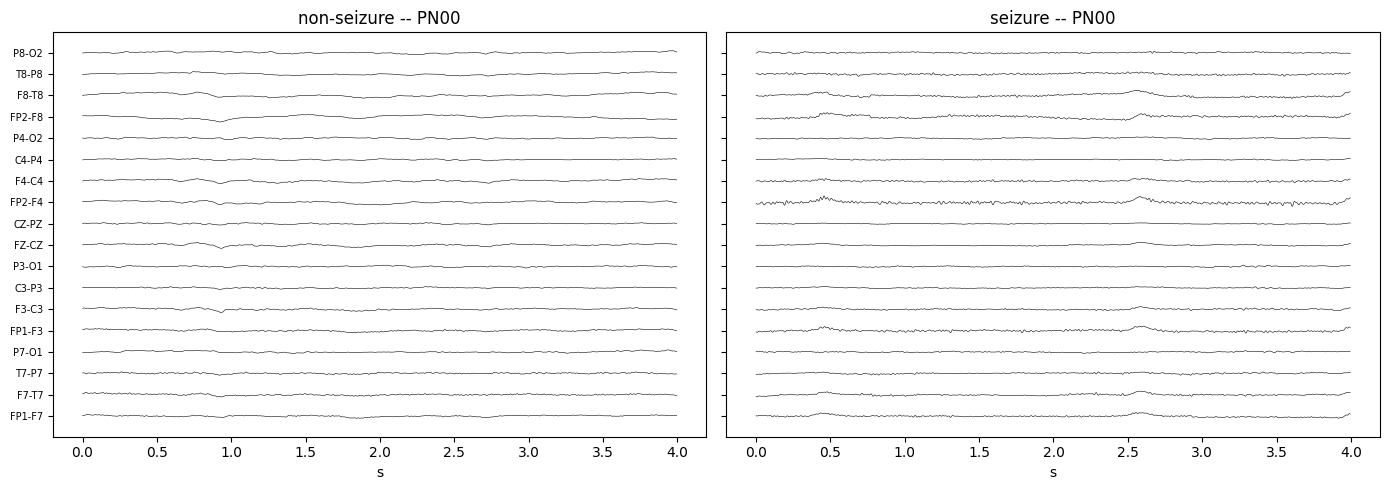

In [17]:
# 7.1 Does a window labelled "seizure" actually look ictal?
sz = S1[(S1.label == 1) & (S1.dataset == "SienaScalp")].sample(1, random_state=SEED).iloc[0]
bg = S1[(S1.label == 0) & (S1.subject_key == sz.subject_key)].sample(1, random_state=SEED).iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, row, title in zip(axes, [bg, sz], ["non-seizure", "seizure"]):
    with h5py.File(row.path, "r") as f:
        w = f["signal"][:, row.start:row.start + row.n] * 1e6
    t = np.arange(w.shape[1]) / TARGET_SFREQ
    for i in range(N_CH):
        ax.plot(t, w[i] + i * 300, lw=0.4, color="k")
    ax.set_title(f"{title} -- {row.subject}")
    ax.set_xlabel("s")
axes[0].set_yticks(np.arange(N_CH) * 300)
axes[0].set_yticklabels(CANONICAL_18, fontsize=7)
plt.tight_layout()
plt.savefig(WIN_ROOT / "sanity_trace.png", dpi=120, bbox_inches="tight")
plt.show()


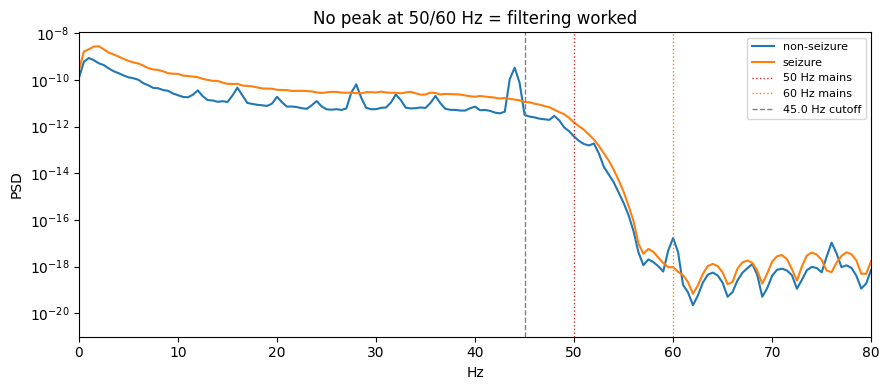

In [18]:
# 7.2 Spectra should separate, and show no mains peak (proof the notch/bandpass worked)
from scipy.signal import welch

def mean_psd(df, k=150):
    acc = None
    for _, r in df.sample(min(k, len(df)), random_state=SEED).iterrows():
        with h5py.File(r.path, "r") as f:
            w = f["signal"][:, r.start:r.start + r.n]
        fq, p = welch(w, fs=TARGET_SFREQ, nperseg=min(w.shape[1], 512), axis=-1)
        acc = p.mean(0) if acc is None else acc + p.mean(0)
    return fq, acc / k

f1, p_sz = mean_psd(S1[S1.label == 1])
_, p_bg = mean_psd(S1[S1.label == 0])
plt.figure(figsize=(9, 4))
plt.semilogy(f1, p_bg, label="non-seizure")
plt.semilogy(f1, p_sz, label="seizure")
for hz, c in [(50, "tab:red"), (60, "tab:orange")]:
    plt.axvline(hz, ls=":", c=c, lw=1, label=f"{hz} Hz mains")
plt.axvline(BP_HIGH, ls="--", c="grey", lw=1, label=f"{BP_HIGH} Hz cutoff")
plt.xlim(0, 80)
plt.xlabel("Hz")
plt.ylabel("PSD")
plt.legend(fontsize=8)
plt.title("No peak at 50/60 Hz = filtering worked")
plt.tight_layout()
plt.savefig(WIN_ROOT / "sanity_psd.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Save the shared manifest

Everything the model notebooks need to start training without touching raw EDF again.

In [19]:
MANIFEST = dict(
    seed=SEED, channels=CANONICAL_18, n_channels=N_CH, sfreq=TARGET_SFREQ,
    bandpass=[BP_LOW, BP_HIGH], notch=LINE_FREQ,
    stage1=dict(window_s=WIN1_S, bg_stride_s=BG_STRIDE_S, sz_stride_s=SZ_STRIDE_S,
                min_overlap=MIN_OVERLAP, buffer_s=BUFFER_S,
                n_windows=len(S1), n_subjects=int(S1.subject_key.nunique()),
                n_events=int(S1[S1.label == 1].event_id.nunique())),
    stage2=dict(window_s=WIN2_S, stride_s=WIN2_STRIDE_S,
                class_names=CLASS_NAMES, class_to_idx=CLASS_TO_IDX,
                n_windows=len(S2), n_events=int(S2.event_id.nunique()),
                n_patients=int(S2.subject.nunique())),
    subtype_by_patient=SUBTYPE,
    paths=dict(recordings=str(REC_ROOT), windows=str(WIN_ROOT)),
)
(WIN_ROOT / "manifest.json").write_text(json.dumps(MANIFEST, indent=2))

print(json.dumps({k: v for k, v in MANIFEST.items() if k in ("stage1", "stage2", "bandpass", "notch")}, indent=2))
print(f"\nwritten to {WIN_ROOT}/")
for f in sorted(WIN_ROOT.iterdir()):
    print("  ", f.name)


{
  "bandpass": [
    0.5,
    45.0
  ],
  "notch": {
    "CHB-MIT": 60.0,
    "SienaScalp": 50.0
  },
  "stage1": {
    "window_s": 4.0,
    "bg_stride_s": 4.0,
    "sz_stride_s": 1.0,
    "min_overlap": 0.5,
    "buffer_s": 300.0,
    "n_windows": 928154,
    "n_subjects": 38,
    "n_events": 199
  },
  "stage2": {
    "window_s": 10.0,
    "stride_s": 2.0,
    "class_names": [
      "focal_aware",
      "focal_impaired_awareness",
      "focal_to_bilateral_tonic_clonic"
    ],
    "class_to_idx": {
      "focal_aware": 0,
      "focal_impaired_awareness": 1,
      "focal_to_bilateral_tonic_clonic": 2
    },
    "n_windows": 1824,
    "n_events": 45,
    "n_patients": 13
  }
}

written to ..\data\harmonized\windows/
   manifest.json
   sanity_psd.png
   sanity_trace.png
   stage1_windows.parquet
   stage2_windows.parquet


## 9. What model notebooks must respect

Both datasets now sit on one montage, one channel order, one sampling rate, with parsed
labels and windowed indices. Three rules carry forward, not stylistic preferences:

1. **Split on `subject_key`, always.** Leave-one-subject-out or GroupKFold on patient ID.
   Never a random window split -- adjacent and overlapping windows from one patient landing
   on both sides of a split inflates every metric.
2. **Never report accuracy alone.** At the class imbalance in \S6, "always predict
   non-seizure" scores above 99%. Report sensitivity, specificity, AUPRC, AUROC, and false
   alarms per hour.
3. **Stage 2 is scored per event, with per-patient labels** (\S2.3). Run the interictal-only
   adversarial control before believing any subtype number.

**Ethics.** Both datasets are de-identified and released for research use (CHB-MIT via
PhysioNet; Siena Scalp under University of Siena Ethical Committee approval, Declaration of
Helsinki, with patient consent). Anything built on top of this is a research prototype, not
a diagnostic device.